# Figure 6 · The resonance enhancement is not Q: d33 from an on-resonance amplitude

Production notebook for main-text Fig. 6 (Nature Communications style, 180 mm).
Analysis details and checks are in notebooks 06 (transfer table), 05a (lever frame) and SIa
(InvOLS). This notebook recomputes only what the figure shows.

Stiff probe (SCM-PIT) on PPLN, two-domain bias survey: 8 positions × 7 biases × 2 domains,
500 nN, V_ac = 1 V, run R2 (the stiff probe after a load ladder had stabilised the tip; the earlier run R1 on the same lever is in the SI).
- **Positions** are in the lever frame, x − x₀, with x₀ from the survey's own force curves
  (notebook 05a).
- **InvOLS** is each stop's own force curve (Phase 2f). AmpInvOLS = InvOLS/32 is confirmed.
- **E(x) = |P_CR1| / |P_QS|** uses two-domain P, which is immune to any domain-independent
  additive background (SI-b).
- **Domain contact potential.** If the two domains have different contact potentials, a term
  −b(x)·(V₁ − V₂)/2 survives in P. It has the electrostatic spatial shape b(x), which vanishes
  only at the electrostatic blind spot (near the tip for displacement detection). It is fitted
  in the quasi-static channel assuming uniform d33 (`domains.cpd_split`) and removed from both
  channels. Raw quasi-static values are shown as a ghost trace in panel b.
- **Blind EB prediction.** For each run, one contact state is fitted to that run's survey data:
  the CR1–CR3 frequencies, Q₁ and the static InvOLS shape. It sees no amplitude, no E and no
  node positions (`eb_fit`, package forward model).
  - Central curve: each residual block weighted by its known uncertainty. Frequencies use
    σ = 1.5 %, the shared-geometry EB floor from Phase 2g; static shape σ = 2 % (InvOLS
    repeatability); Q σ = 5 %. The cone stiffness is free (lower bound 10^-1.5 k_lever).
  - Band: the same fit with σ_f = 1 % and 2 % and with the archived weighting (frequencies ×3).
    It shows how much the prediction depends on fit choices.

In [1]:
%matplotlib inline
import sys, pathlib
# make the paper package importable when running from notebooks/
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fmmpaper as F
from fmmpaper import io, axis, spectra, domains, recon, plotting as fp, results
fp.setup()
print(F.config.describe())

project : /home/claude/work/paper_analysis
data_root: /mnt/user-data/uploads/ActiveModeMap  (ok)
amm_repo : /home/claude/work  (ok)
eb_repo  : C:\Users\lz1\Documents\Github\EB-Solver-CResonance  (MISSING)
fmm_code_zip: /mnt/user-data/uploads/ActiveModeMap_repo/Manuscript_FMM/FMM_analysis_code.zip  (ok)


In [2]:
import datetime as dt, json
from fmmpaper import calib, eb_fit, axis
VAC, L_UM = 1.0, 226.5
RUNS = {"R2": ("DomainsB_SCMPIT_R2", dt.datetime(2026, 9, 20, 22))}     # run R1 (same lever) is in the SI
CACHE = F.config.RESULTS_DIR / "_cache_fig6.json"
cache = json.loads(CACHE.read_text()) if CACHE.exists() else {}
T = {}
for tag, (camp, d0) in RUNS.items():
    s = F.load(f"scmpitB_{tag.lower()}_bias")
    tl = calib.timeline(camp, d0)
    x0 = float(calib.frame_anchors(camp, tl, L_UM).set_index("stage").loc["10_bias_survey", "x0"])
    pre = axis.invols_interpolator(F.load(f"scmpitB_{tag.lower()}_preflight"))
    # each stop's own force curve (ratio to pre-flight); stage median where a stop has none (R1's first stop)
    inv_fn = lambda x, _pre=pre, _tl=tl: float(np.atleast_1d(_pre(x))[0]) * float(calib.factor_at(_tl, "10_bias_survey", x)[0])
    t = domains.transfer_table(s, inv_fn, VAC)
    t["x_lever_um"] = t.x_um - x0
    # contact state for the blind fit: frequencies from the 0 V spot-1 spectra, Q1, static shape
    i0 = int(np.intersect1d(s.where(bias_V=0), s.where(spot=1))[0])
    fr = [float(np.median(spectra.peaks_along_x(s.freq_Hz, s.Z[i0], s.probe.bands_Hz[b])["f_Hz"])) for b in ("CR1", "CR2", "CR3")]
    xs = t.x_lever_um.values; keep = xs < L_UM - 10
    st = eb_fit.ContactState(f"{tag} survey", np.array(fr), float(np.nanmedian(t.Q)), xs[keep], t.invols.values[keep], L_um=L_UM)
    VARIANTS = {"central": dict(sig_f=0.015, sig_static=0.02, sig_Q=0.05), "sf1": dict(sig_f=0.01, sig_static=0.02, sig_Q=0.05),
                "sf2": dict(sig_f=0.02, sig_static=0.02, sig_Q=0.05), "archived": {}}
    lo = eb_fit.LO.copy(); lo[1] = -1.5
    cache.setdefault(tag, {})
    for vk, kw in VARIANTS.items():
        if vk not in cache[tag]:
            r = eb_fit.fit(st, use_nodes=False, lo=lo, **kw)
            cache[tag][vk] = dict(p=r.x.tolist(), summary={k: v for k, v in eb_fit.summarize(r.x, st).items() if k != "nodes_meas_um"})
            CACHE.write_text(json.dumps(cache, default=float))
    Es = {vk: eb_fit.enhancement(np.array(cache[tag][vk]["p"]), st, t.x_lever_um.values)[0] for vk in VARIANTS}
    t["E_eb"] = Es["central"]
    t["E_eb_lo"] = np.min(list(Es.values()), axis=0); t["E_eb_hi"] = np.max(list(Es.values()), axis=0)
    t["d33_cr_eb"] = domains.d33_from_enhancement(t, Es["central"], VAC)
    t["d33_cr_eb_lo"] = domains.d33_from_enhancement(t, t.E_eb_hi.values, VAC)
    t["d33_cr_eb_hi"] = domains.d33_from_enhancement(t, t.E_eb_lo.values, VAC)
    contact = L_UM - cache[tag]["central"]["summary"]["setback_um"]
    t["interior"] = t.x_lever_um < contact - 3          # at/after the tip contact the ratio is ill-defined
    # domain-dependent contact potential: P = p + delta*b(x); delta from the QS channel (uniform d33), applied to both channels
    cs = domains.cpd_split(t, mask=t.interior)
    for c in ("d33_qs", "E", "d33_cr_eb", "d33_cr_over_Q"):
        t[c + "_raw"] = t[c]
    t["d33_qs"] = cs["d33_qs_corr"]; t["E"] = cs["E_corr"]
    t["d33_cr_eb"] = cs["P_cr_corr"] / t.E_eb
    t["d33_cr_eb_lo"] = cs["P_cr_corr"] / t.E_eb_hi; t["d33_cr_eb_hi"] = cs["P_cr_corr"] / t.E_eb_lo
    t["d33_cr_over_Q"] = cs["P_cr_corr"] / t.Q
    print(f"{tag}: domain contact-potential term delta = {1e3*cs['delta_V']:+.0f} mV (V1 - V2 = {1e3*cs['dV_domains_V']:+.0f} mV), "
          f"uniform QS d33 {cs['d33_uniform']:.2f} pm/V")
    T[tag] = dict(table=t, x0=x0, contact_um=contact, state=st, cpd={k: cs[k] for k in ("delta_V", "dV_domains_V", "d33_uniform")})
    sm = cache[tag]["central"]["summary"]
    print(f"{tag}: x0 {x0:.1f} um, contact at {contact:.1f} um from clamp, k*/k {sm['k_ratio']:.0f}, kcone/k {sm['kcone_ratio']:.2f}, "
          f"setback {sm['setback_um']:.1f}, tip h {sm['tip_height_um']:.1f}, CR err % {sm['cr_err_pct']}, Q model {sm['Q_model']:.0f} vs {st.Q1:.0f}")
pd.concat({k: v["table"][["x_lever_um", "invols", "Q", "E", "E_eb", "d33_qs", "d33_cr_eb", "d33_cr_over_Q", "interior"]]
           for k, v in T.items()}).round(3)

R2: domain contact-potential term delta = +635 mV (V1 - V2 = -1271 mV), uniform QS d33 7.58 pm/V
R2: x0 24.1 um, contact at 221.3 um from clamp, k*/k 734, kcone/k 0.23, setback 5.2, tip h 7.8, CR err % [-1.44, 0.94, -0.4], Q model 239 vs 238


x_lever_um  invols        Q        E     E_eb  d33_qs  d33_cr_eb  \
R2 0        47.9     0.0  239.439  611.752  623.662   7.464      7.321   
   1        70.8     0.0  241.358  497.576  531.799   7.610      7.120   
   2        93.6     0.0  233.698  363.812  437.959   7.690      6.388   
   3       116.5     0.0  237.018  323.455  344.008   7.591      7.138   
   4       139.3     0.0  243.880  235.703  253.855   7.628      7.082   
   5       162.2     0.0  245.106  164.310  169.871   7.529      7.283   
   6       185.0     0.0  232.351   88.610   95.714   7.557      6.996   
   7       207.9     0.0  234.376   31.462   33.217   7.561      7.161   

      d33_cr_over_Q  interior  
R2 0         19.070      True  
   1         15.688      True  
   2         11.972      True  
   3         10.359      True  
   4          7.372      True  
   5          5.047      True  
   6          2.882      True  
   7          1.015      True

In [3]:
rows = []
for tag, v in T.items():
    t = v["table"]; m = t.interior
    rat = (t.E / t.E_eb)[m]; rat_raw = (t.E_raw / t.E_eb)[m]
    for route, col in (("quasi-static, raw", "d33_qs_raw"), ("quasi-static, domain-CPD corrected", "d33_qs"),
                       ("CR1 / E_EB (blind), corrected", "d33_cr_eb"), ("CR1 / Q, corrected", "d33_cr_over_Q")):
        d = t[col][m]
        rows.append(dict(run=tag, route=route, median_pm_per_V=d.median(), spread_max_over_min=d.max() / d.min(),
                         sd_over_median_pct=100 * d.std() / d.median()))
    print(f"{tag}: E {t.E[m].min():.0f}-{t.E[m].max():.0f} (x{t.E[m].max()/t.E[m].min():.0f}) vs Q {t.Q[m].mean():.0f} +- {t.Q[m].std():.0f};"
          f" E_meas/E_EB {rat.min():.2f}-{rat.max():.2f} (median {rat.median():.2f}); before the CPD correction {rat_raw.min():.2f}-{rat_raw.max():.2f}")
summary = pd.DataFrame(rows); summary.round(3)

R2: E 31-612 (x19) vs Q 238 +- 5; E_meas/E_EB 0.83-0.98 (median 0.94); before the CPD correction 0.77-1.05


,run,route,median_pm_per_V,spread_max_over_min,sd_over_median_pct
0,R2,"quasi-static, raw",8.876,1.282,9.178
1,R2,"quasi-static, domain-CPD corrected",7.576,1.030,0.897
2,R2,"CR1 / E_EB (blind), corrected",7.129,1.146,4.086
3,R2,"CR1 / Q, corrected",8.866,18.788,70.830


In [4]:
lx = pd.DataFrame(json.loads((F.config.RESULTS_DIR / "si_invols_drift.json").read_text())["values"]["load_extension"])
tA = T["R2"]["table"].sort_values("x_lever_um")
X_A_STAGE = 154.9                                    # position A (load extension, R2 stage 41)
camp, d0 = RUNS["R2"]
tlR2 = calib.timeline(camp, d0)
anR2 = calib.frame_anchors(camp, tlR2, L_UM)
t_load = tlR2[tlR2.stage == "41_bias_vs_load"].t.median()
x0_load = float(calib.x0_at(anR2, t_load)[0])
xA_survey_lever = X_A_STAGE - T["R2"]["x0"]
xA_load_lever = X_A_STAGE - x0_load
d_stage1_A_stage = float(np.interp(xA_survey_lever, tA.x_lever_um, tA.d33_qs))   # same stage position (as in SIa)
d_stage1_A = float(np.interp(xA_load_lever, tA.x_lever_um, tA.d33_qs))            # same LEVER position
# domain-CPD correction at A with R2's delta (assumes V1 - V2 does not change with load)
bvl = F.load("scmpitB_r2_s4")["bias_vs_load"]; dR2 = T["R2"]["cpd"]["delta_V"]
cz = lambda v: complex(v[0], v[1])
fac = []
for L in lx.load_nN:
    c = bvl[str(int(L))]["coef"] if str(int(L)) in bvl else bvl[L]["coef"]
    P = (cz(c["qs_a1"]) - cz(c["qs_a2"])) / 2; b = (cz(c["qs_b1"]) + cz(c["qs_b2"])) / 2
    fac.append(abs(P - dR2 * b) / abs(P))
lx["cpd_factor"] = fac
lx["d33_corr"] = lx.d33_measured_invols * lx.cpd_factor
lx["vs_survey_same_lever_pos_pct"] = 100 * (lx.d33_corr / d_stage1_A - 1)
print(f"A = stage {X_A_STAGE} um: lever position {xA_survey_lever:.1f} um during the survey, {xA_load_lever:.1f} um during the "
      f"load series (x0 {T['R2']['x0']:.1f} -> {x0_load:.1f} um)")
print(f"survey d33_QS at A: {d_stage1_A_stage:.2f} pm/V at the same stage position, {d_stage1_A:.2f} at the same lever position")
lx[["load_nN", "d33_as_reported", "d33_measured_invols", "cpd_factor", "d33_corr", "vs_survey_same_lever_pos_pct"]].round(3)

A = stage 154.9 um: lever position 130.8 um during the survey, 116.0 um during the load series (x0 24.1 -> 38.9 um)
survey d33_QS at A: 7.61 pm/V at the same stage position, 7.59 at the same lever position


,load_nN,d33_as_reported,d33_measured_invols,cpd_factor,d33_corr,vs_survey_same_lever_pos_pct
0,100.0,6.666,8.206,0.826,6.776,-10.761
1,300.0,7.357,9.183,0.840,7.714,1.595
2,500.0,7.530,9.222,0.845,7.790,2.598


## Images at resonance (stage 5 of each run)

- 6 µm frames at positions A (stage 154.9 µm) and B (stage 232 µm): QS at 0 V; CR1 at 0 V and
  at the imaging null V̄ (R2 also at V̄/2).
- Positions are in the lever frame at imaging time.
- Domain contact-potential correction per pixel: V₁ = V̄ − δ, V₂ = V̄ + δ, with δ from the survey
  and b from the survey's b/P at that lever position (`fmmpaper.images`).
- **Calibration check.** Image E = |P_CR1|/|P_QS| from the same frames (two-domain contrast, 0 V),
  against the survey's two-domain E at the same lever position (same definition) and the blind
  EB prediction.

In [5]:
from fmmpaper import images
IMG = {"R2": ("DomainsB_SCMPIT_R2/50_quant_imaging")}
img_rows, IM = [], {}
for tag, rel in IMG.items():
    root = F.config.data_root() / rel
    J = json.loads((root / "image_cr1_quant.json").read_text()); ims = {im["name"]: im for im in J["images"]}
    camp, d0 = RUNS[tag]; tl_ = calib.timeline(camp, d0); an_ = calib.frame_anchors(camp, tl_, L_UM)
    x0i = float(calib.x0_at(an_, np.datetime64(J["started"].replace(" ", "T")))[0])
    t = T[tag]["table"].sort_values("x_lever_um"); xl = t.x_lever_um.values
    cplx = lambda a, b: t[a].values + 1j * t[b].values
    rq = cplx("bq_re", "bq_im") / cplx("Pq_re", "Pq_im"); rc = cplx("bc_re", "bc_im") / cplx("Pc_re", "Pc_im")
    ri = lambda r, x: np.interp(x, xl, r.real) + 1j * np.interp(x, xl, r.imag)
    delta = T[tag]["cpd"]["delta_V"]; Vbar = float(J["v_cpd_V"]); V1, V2 = Vbar - delta, Vbar + delta
    p_c = np.array(cache[tag]["central"]["p"])
    for pos, xs in (("A", 154.9), ("B", 232.0)):
        X = xs - x0i
        rd = lambda n: images.read(root / ims[n]["path"].split(chr(92))[-1], ims[n]["drive_V"])
        zq, zc0 = rd(f"{pos}_qs20k_0V"), rd(f"{pos}_cr1_0V")
        vname = next(n for n in ims if n.startswith(f"{pos}_cr1_V") and abs(ims[n]["bias_V"] - Vbar) < 1e-6)
        zcv = rd(vname)
        m1, m2 = images.domain_masks(zc0)
        E_img = abs(images.domain_contrast(zc0, m1, m2)) / abs(images.domain_contrast(zq, m1, m2))
        E_srv = float(np.interp(X, xl, t.E_raw.values))
        E_eb = float(eb_fit.enhancement(p_c, T[tag]["state"], [X])[0][0])
        pq = images.cpd_correct(zq, m1, m2, 0.0, V1, V2, ri(rq, X), delta)
        pc = images.cpd_correct(zcv, m1, m2, Vbar, V1, V2, ri(rc, X), delta)
        e1, e2 = images.interior(m1), images.interior(m2)
        d_q, d_c = np.abs(pq), np.abs(pc) / E_eb
        IM[(tag, pos)] = dict(qs_raw=np.abs(zq), qs=d_q, cr=d_c, e1=e1, e2=e2, E_eb=E_eb)
        img_rows.append(dict(run=tag, pos=pos, lever_um=X, E_image=E_img, E_survey=E_srv, E_blindEB=E_eb,
                             image_over_survey=E_img / E_srv,
                             qs_raw_1=np.median(np.abs(zq)[e1]), qs_raw_2=np.median(np.abs(zq)[e2]),
                             qs_corr_1=np.median(d_q[e1]), qs_corr_2=np.median(d_q[e2]),
                             cr_EB_1=np.median(d_c[e1]), cr_EB_2=np.median(d_c[e2]),
                             cr_img_1=np.median(np.abs(pc)[e1] / E_img), cr_img_2=np.median(np.abs(pc)[e2] / E_img),
                             d33_spectroscopy=T[tag]["cpd"]["d33_uniform"]))
imgtab = pd.DataFrame(img_rows); imgtab.round(3)

,run,pos,lever_um,E_image,E_survey,E_blindEB,image_over_survey,qs_raw_1,qs_raw_2,qs_corr_1,qs_corr_2,cr_EB_1,cr_EB_2,cr_img_1,cr_img_2,d33_spectroscopy
0,R2,A,129.786,177.557,265.453,290.865,0.669,6.516,11.323,7.230,8.455,4.950,4.887,8.109,8.006,7.579
1,R2,B,206.886,30.952,37.509,35.703,0.825,7.240,8.761,7.383,8.189,6.374,6.289,7.352,7.254,7.579


## The figure

[PosixPath('/home/claude/work/paper_analysis/figures/Fig6_E_not_Q_d33.png'),
 PosixPath('/home/claude/work/paper_analysis/figures/Fig6_E_not_Q_d33.pdf')]

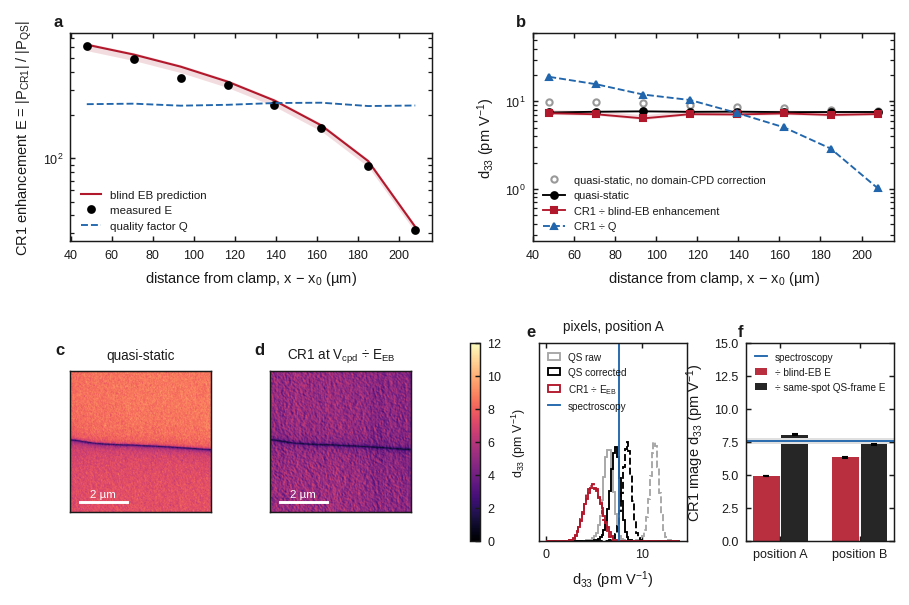

In [6]:
from matplotlib.gridspec import GridSpec
fig = plt.figure(figsize=(fp.WIDTH_IN["double"], fp.WIDTH_IN["double"] * 0.62))
gs = GridSpec(2, 1, figure=fig, height_ratios=[1, 0.95], hspace=0.5)
g1 = gs[0].subgridspec(1, 2, wspace=0.28); g2 = gs[1].subgridspec(1, 5, wspace=0.5, width_ratios=[1, 1, 0.07, 1.05, 1.05])
axa, axb = (fig.add_subplot(g1[0, i]) for i in range(2))
axd, axe = fig.add_subplot(g2[0, 0]), fig.add_subplot(g2[0, 1]); cax = fig.add_subplot(g2[0, 2])
axf, axg = fig.add_subplot(g2[0, 3]), fig.add_subplot(g2[0, 4])
t = T["R2"]["table"]; ti, te = t[t.interior], t[~t.interior]

# a  E(x) vs Q, with the blind EB prediction
axa.fill_between(t.x_lever_um, t.E_eb_lo, t.E_eb_hi, color=fp.C["ebgp"], alpha=0.15, lw=0)
axa.plot(t.x_lever_um, t.E_eb, color=fp.C["ebgp"], lw=1.0, label="blind EB prediction")
axa.semilogy(ti.x_lever_um, ti.E, "o", color="k", ms=3.2, label="measured E")
axa.semilogy(t.x_lever_um, t.Q, "--", color=fp.C["gp"], lw=0.9, label="quality factor Q")
axa.set_xlabel("distance from clamp, x − x$_0$ (µm)"); axa.set_ylabel("CR1 enhancement E = |P$_{CR1}$| / |P$_{QS}$|")
axa.legend(loc="lower left", fontsize=5.5, handlelength=1.8)
fp.panel_label(axa, "a")

# b  three d33 routes along the lever
ROUTE = {"d33_qs": ("quasi-static", "k", "o", "-"),
         "d33_cr_eb": ("CR1 ÷ blind-EB enhancement", fp.C["ebgp"], "s", "-"),
         "d33_cr_over_Q": ("CR1 ÷ Q", fp.C["gp"], "^", "--")}
tb = t[t.interior]
axb.fill_between(tb.x_lever_um, tb.d33_cr_eb_lo, tb.d33_cr_eb_hi, color=fp.C["ebgp"], alpha=0.15, lw=0)
axb.plot(tb.x_lever_um, tb.d33_qs_raw, "o", color="0.6", mfc="w", ms=3, lw=0, label="quasi-static, no domain-CPD correction")
for col, (lab, c, mk, ls) in ROUTE.items():
    axb.plot(tb.x_lever_um, tb[col], marker=mk, ls=ls, color=c, ms=3.2, lw=0.9, label=lab)
axb.set_yscale("log"); axb.set_ylim(0.25, 60)
axb.set_xlabel("distance from clamp, x − x$_0$ (µm)"); axb.set_ylabel("d$_{33}$ (pm V$^{-1}$)")
axb.legend(loc="lower left", fontsize=5.3)
fp.panel_label(axb, "b")

# c, d  maps at position A
g = IM[("R2", "A")]
for ax, key, title in ((axd, "qs", "quasi-static"), (axe, "cr", "CR1 at V$_{cpd}$ ÷ E$_{EB}$")):
    im_ = ax.imshow(g[key], cmap="magma", vmin=0, vmax=12, origin="lower", extent=[0, 6, 0, 6])
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(title, fontsize=6.5)
    ax.plot([0.4, 2.4], [0.45, 0.45], "w-", lw=1.4); ax.text(1.4, 0.65, "2 µm", color="w", ha="center", fontsize=5.5)
cb = fig.colorbar(im_, cax=cax); cb.set_label("d$_{33}$ (pm V$^{-1}$)", fontsize=6)
fp.panel_label(axd, "c", dx=-0.04, dy=1.1); fp.panel_label(axe, "d", dx=-0.04, dy=1.1)

# e  per-domain d33 distributions at A
bins = np.linspace(0, 14, 71)
for key, c, lab in (("qs_raw", "0.65", "QS raw"), ("qs", "k", "QS corrected"), ("cr", fp.C["ebgp"], "CR1 ÷ E$_{EB}$")):
    for dom, ls in (("e1", "-"), ("e2", "--")):
        axf.hist(g[key][g[dom]], bins=bins, histtype="step", color=c, ls=ls, lw=0.9, density=True, label=lab if dom == "e1" else None)
axf.axvline(T["R2"]["cpd"]["d33_uniform"], color=fp.C["gp"], lw=0.9, label="spectroscopy")
axf.set_xlabel("d$_{33}$ (pm V$^{-1}$)"); axf.set_yticks([]); axf.set_title("pixels, position A", fontsize=6.5)
axf.set_ylim(0, axf.get_ylim()[1] * 1.9)
axf.legend(fontsize=4.8, loc="upper left", handlelength=1.2)
fp.panel_label(axf, "e")

# f  calibrating the resonance image: blind E vs a quasi-static frame at the same spot
d33s = T["R2"]["cpd"]["d33_uniform"]
for i, r in imgtab.reset_index(drop=True).iterrows():
    for j, (col, c, lab) in enumerate((("cr_EB", fp.C["ebgp"], "÷ blind-EB E"), ("cr_img", "k", "÷ same-spot QS-frame E"))):
        v = [r[f"{col}_1"], r[f"{col}_2"]]
        axg.bar(i + (j - 0.5) * 0.36, np.mean(v), width=0.34, color=c, alpha=0.85 if j else 0.9,
                yerr=[[np.mean(v) - min(v)], [max(v) - np.mean(v)]], capsize=1.5, error_kw=dict(lw=0.6),
                label=lab if i == 0 else None)
axg.axhspan(d33s * 0.97, d33s * 1.03, color="0.88", lw=0); axg.axhline(d33s, color=fp.C["gp"], lw=0.9, label="spectroscopy")
axg.set_xticks(range(len(imgtab))); axg.set_xticklabels([f"position {p}" for p in imgtab.pos])
axg.set_ylabel("CR1 image d$_{33}$ (pm V$^{-1}$)"); axg.set_ylim(0, 15)
axg.legend(loc="upper left", fontsize=4.8, handlelength=1.2)
fp.panel_label(axg, "f")
fp.save(fig, "Fig6_E_not_Q_d33")

In [7]:
results.save("fig6_main", dict(runs={k: dict(x0=v["x0"], contact_um=v["contact_um"], fit=cache[k], cpd=v["cpd"],
                                            table=v["table"].to_dict("records")) for k, v in T.items()},
                               summary=summary.to_dict("records"), load=lx.to_dict("records"), d33_stage1_A=d_stage1_A,
                               images=imgtab.to_dict("records")),
             table=summary)

PosixPath('/home/claude/work/paper_analysis/results/fig6_main.json')